In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from collections import deque
%matplotlib inline

In [3]:
def f(n):
    # return 3*x**2-4*x+5
    t=(math.exp(2*x)-1)/(math.exp(2*x)+1)
    return t

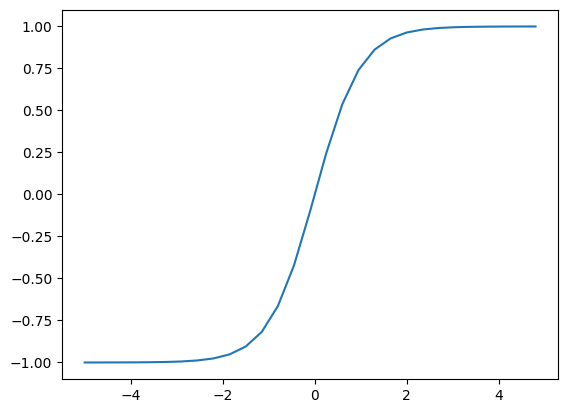

In [9]:
X=np.arange(-5,5,0.35)
y=[]
for x in X:
    y.append(f(x))
plt.plot(X,y)

In [ ]:
h=0.0001
#input
a=3.0
b=-3.0
c=10.0
d1=a+b++c
a+=h
d2=a+b+c
slope=(d2-d1)/h


<h1>Value

In [9]:
class Value:
    
    def __init__(self,data,_childeren=(),_op='',label=''):
        self.data=data
        self._prev=set(_childeren)
        self._op=_op
        self.label=label
        self.grad = 0.0 #gradient
        self._backward=lambda: None #if it a leaf node then it will do nothing because it doesn't children that can have effect on it 
        
    def __repr__(self):
        return f"Value|data={self.data}"
        
    def __add__(self,other):
         other=other if  isinstance(other,Value) else Value(other)
         out=Value(self.data+other.data,(self,other),'+') 
         def _backward():
             self.grad+=1.0*out.grad #accumlating
             other.grad+=1.0*out.grad
         out._backward=_backward
         return out
    def _radd_(self,other):
        return self+other

    def __neg__(self):
        return self*-1
        
    def __sub__(self,other):
        return self + (-other)
        
    def __mul__(self,other):
         other=other if  isinstance(other,Value) else Value(other)
         out=Value(self.data*other.data,(self,other),'*')
         def _backward():
             self.grad+=other.data*out.grad
             other.grad+=self.data*out.grad
         out._backward=_backward
         return out

    def __rmul__ (self,other): #right multipllcation (if python can't do like 2*a it will call this funciton to check if by chance a knows how to  multiply 2
        return self * other #here i forced python to take my object of type value first( on the left )

    def __pow__(self,other):
         assert isinstance(other,(int,float)),"only supporting int/float powers for now"
         out=Value(self.data**other,(self,),f"**{other}")
         def _backward():
             self.grad+=other*(self.data**(other-1))*out.grad
         out._backward=_backward
         return out

    def __truediv__(self,other):
        return self*other**-1
        
    def tanh(self):
        x=self.data
        t=(math.exp(2*x)-1)/(math.exp(2*x)+1)
        out=Value(t,(self,),'tanh')
        def _backward():
            self.grad+=(1 - t**2)*out.grad
        out._backward=_backward
        return out
        
    def exp(self):
        x=self.data
        out=Value(math.exp(x),(self,),label='exp')
        def _backward():
            self.grad+=out.data*out.grad
        out._backward=_backward
        return out        
        
    def backward(self):
        topo=[] #topological sort (because i can't do backpropagation for node until i know the derivative of all nodes to it (to apply chain rule correctly)
        visited=set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad=1.0
        for node in reversed(topo):
            node._backward()

In [ ]:
a=Value(2.0,label='a')
b=Value(4.0,label='b')
# a*2
# 2*a
# a.exp()
# a**-1
# a / b
a-b

In [ ]:
a=Value(3.0,label='a')
b=Value(-3.0,label='b')
c=Value(10.0,label='c')
# a+b + c
# g=a*b
d=a*b+c
d._prev
# d._op
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
l = d * f; L.label = 'l'
#manual backpropagation
l.grad=1
f.grad=d.data
d.grad=f.data
c.grad=f.data #chain rule (node +)
e.grad=f.data#chain rule (node +)
a.grad=b.data*e.grad #local derivate * (chain rule derivatives until it )
b.grad=a.data*e.grad #local derivate * (chain rule derivatives until it )
b.grad

In [ ]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
  if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
     dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [ ]:
def lol():
    h=0.001
    a=Value(2.0,label='a')
    b=Value(-3.0,label='b')
    c=Value(10.0,label='c')
    e=a*b; e.label='e'
    d=e+c;d.label='d'
    f = Value(-2.0, label='f')
    l=d*f;l.label='l'
    l1=l.data

    a=Value(2.0,label='a')
    b=Value(-3.0,label='b')
    b.data+=h
    c=Value(10.0,label='c')
    # c.data +=h
    e=a*b; e.label='e'
    # e.data +=h
    d=e+c;d.label='d'
    f = Value(-2.0 , label='f')
    l=d*f;l.label='l'
    l2=l.data
    print((l2-l1)/h)
lol()
    

<h1>tracing

In [12]:
# def trace(root):
#   # builds a set of all nodes and edges in a graph
#   nodes, edges = set(), set()
#   def build(v):
#     if v not in nodes:
#       nodes.add(v)
#       print('|',v.label,'|',v.data,'|',v._op ,'|',v._prev,'|',v.grad,'|')  
#       for child in v._prev:
#         edges.add((child, v))
#         build(child)
#   build(root)
  # return nodes, edges
nodes= set()
def trace(root):
        visited=set()
        visited.add(root)
        queue=deque([root])
        while queue:
            current=queue.popleft()
            print('|',current.label,'|',current.data,'|',current._op ,'|',current._prev,'|',current.grad,'|') 
            for c in current._prev:
                    if c not in visited:
                        visited.add(c)
                        queue.append(c)
        nodes=visited
        # return nodes
a=Value(2.0,label='a')
b=Value(-3.0,label='b')
c=Value(10.0,label='c')
e=a*b; e.label='e'
d=e+c;d.label='d'
f = Value(-2.0, label='f')
l=d*f;l.label='l'
l1=l.data
trace(l)

| l | -8.0 | * | {Value|data=4.0, Value|data=-2.0} | 0.0 |
| d | 4.0 | + | {Value|data=10.0, Value|data=-6.0} | 0.0 |
| f | -2.0 |  | set() | 0.0 |
| c | 10.0 |  | set() | 0.0 |
| e | -6.0 | * | {Value|data=2.0, Value|data=-3.0} | 0.0 |
| a | 2.0 |  | set() | 0.0 |
| b | -3.0 |  | set() | 0.0 |


<h3>derivative of l respect to d = f
    
<h5>assume f = 2
dl=2(d+h)-2d=2h
dd=h
dl/dd=2h/h=2 congrat it is 2


<h3>derivative of l respect to c =1.0   
<h5>dd/dc??
d = e + c
((c+h+e)-(c+e))/h=1.0
dd/dc=1.0
dd/de=1.0

<h1>Chain Rule
<h5>
    dl/dc???
    dl/dd=-2.0
    dd/dc=1.0
    dd/de=1.0
    dl/dc=dl/dd*dd/dc=-2.0*1.0=-2.0
    
</h5>
<h5>
    dl/da???
    dl/dd=-2.0
    dd/de=1.0
    de/da=b=-3.0
    dl/da=(dl/de)de/da
    dl/da=dl/dd*dd/de*de*da=-2.0*1.0*3*0=-6.0
</h5>

<h1>Back Propagation
<h5>rescursively multiply on the local derivatives</h5>
<h5>it is resursive application of the chain rule</h5>

In [ ]:
a.data +=0.01*a.grad
b.data +=0.01*b.grad
c.data +=0.01*c.grad
f.data +=0.01*f.grad
e = a * b
d = e + c
L = d * f

print(L.data)

In [ ]:
plt.plot(np.arange(-5,5,0.2),np.tanh(np.arange(-5,5,0.2)))
plt.grid()

<h1>one neuron

In [20]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

<h3>manual backpropagation

In [ ]:
o.grad=1.0
#do/dn=(1 - tanh(n)**2)=(1-o.data**2)
n.grad=0.4999999999999999
x1w1x2w2.grad=0.4999999999999999
b.grad=0.4999999999999999
x2w2.grad=0.4999999999999999
x1w1.grad=0.4999999999999999
x2.grad=w2.data*x2w2.grad
w2.grad=x2.data*x2w2.grad
x1.grad=w1.data*x1w1.grad
w1.grad=x1.data*x1w1.grad
trace(o)

<h3>automatic backpropagation

In [21]:
# o.grad=1.0
# o._backward()
# n._backward()
# b._backward()
# x1w1x2w2._backward()
# x1w1._backward()
# x2w2._backward()
o.backward()
# trace(o)

| o | 0.7071067811865476 | tanh | {Value|data=0.8813735870195432} | 1.0 |
| n | 0.8813735870195432 | + | {Value|data=6.881373587019543, Value|data=-6.0} | 0.4999999999999999 |
| b | 6.881373587019543 |  | set() | 0.4999999999999999 |
| x1*w1 + x2*w2 | -6.0 | + | {Value|data=-6.0, Value|data=0.0} | 0.4999999999999999 |
| x1*w1 | -6.0 | * | {Value|data=-3.0, Value|data=2.0} | 0.4999999999999999 |
| x2*w2 | 0.0 | * | {Value|data=0.0, Value|data=1.0} | 0.4999999999999999 |
| w1 | -3.0 |  | set() | 0.9999999999999998 |
| x1 | 2.0 |  | set() | -1.4999999999999996 |
| x2 | 0.0 |  | set() | 0.4999999999999999 |
| w2 | 1.0 |  | set() | 0.0 |


<h3>atomic tanh operation with value datatype

In [22]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
#==========
e= (2*n).exp()
o=(e-1)/(e+1)
#==========
o.label = 'o'
o.backward()
# trace(o)

| o | 0.7071067811865477 | * | {Value|data=4.828427124746192, Value|data=0.1464466094067262} | 1.0 |
|  | 4.828427124746192 | + | {Value|data=-1, Value|data=5.828427124746192} | 0.1464466094067262 |
|  | 0.1464466094067262 | **-1 | {Value|data=6.828427124746192} | 4.828427124746192 |
|  | -1 |  | set() | 0.1464466094067262 |
| exp | 5.828427124746192 |  | {Value|data=1.7627471740390863} | 0.04289321881345247 |
|  | 6.828427124746192 | + | {Value|data=5.828427124746192, Value|data=1} | -0.10355339059327374 |
|  | 1.7627471740390863 | * | {Value|data=2, Value|data=0.8813735870195432} | 0.25 |
|  | 1 |  | set() | -0.10355339059327374 |
|  | 2 |  | set() | 0.2203433967548858 |
| n | 0.8813735870195432 | + | {Value|data=-6.0, Value|data=6.881373587019543} | 0.5 |
| x1*w1 + x2*w2 | -6.0 | + | {Value|data=-6.0, Value|data=0.0} | 0.5 |
| b | 6.881373587019543 |  | set() | 0.5 |
| x1*w1 | -6.0 | * | {Value|data=-3.0, Value|data=2.0} | 0.5 |
| x2*w2 | 0.0 | * | {Value|data=1.0, Value|data=0.0} |

<h1>Neural netwrok

In [426]:
class Neuron:
  
  def __init__(self, nin):
    #nin number of deimenions (inputs) for neuron
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))
  
  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
  
  def parameters(self):
    return self.w + [self.b]

class Layer:
  
  def __init__(self, nin, nout):
    # nln number of deimenions (inputs) for neuron
    # nout the number of neurons in the layer each neurn has one out so it nout
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs #display outs as value not alist if there is just one neuron in ther layer
  
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x) #call them sequentially 
    return x #output of the final layer
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]


<h2>initialize

In [427]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value|data=-0.809159444648524

<h2>small dataset

In [428]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

<h2>Gradien Decent</h2>

In [430]:
for k in range(20):
  
  # forward pass
  ypred = [n(x) for x in xs]

  #loss funciton
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  #zero grad
  for p in n.parameters():
        p.grad=0.0

  # backward pass
  loss.backward()
  
  # update
  for p in n.parameters():
    p.data += -0.1 * p.grad
  
  print(k,'->',loss.data)
  

0 -> 0.01325652955378652
1 -> 0.012507642474534408
2 -> 0.011833023133235566
3 -> 0.011222496029105604
4 -> 0.010667636837707562
5 -> 0.010161412573004432
6 -> 0.009697907304463984
7 -> 0.009272110398753159
8 -> 0.00887975115946114
9 -> 0.00851716836852506
10 -> 0.008181206402652307
11 -> 0.007869131807628355
12 -> 0.007578565778990443
13 -> 0.007307429123147011
14 -> 0.00705389709303572
15 -> 0.006816362097001823
16 -> 0.0065934027302430405
17 -> 0.006383757917486061
18 -> 0.006186305213417639
19 -> 0.006000042505035745


In [ ]:
# print(n.layers[0].neurons[0].w[0].data) #the effect of little change of n.layers[0].neurons[0].w[1] on loss 
#MSE loss
#because we want to tweak in wieghts 's values to close the predicton to the target
#but there is som values need to inscrease and other decrease how we will do it 
#so we need loss function that do backward to it it tweaks the 